
# Técnicas avanzadas de diseño de software

----

## Decoradores y manejadores de contexto en Python 

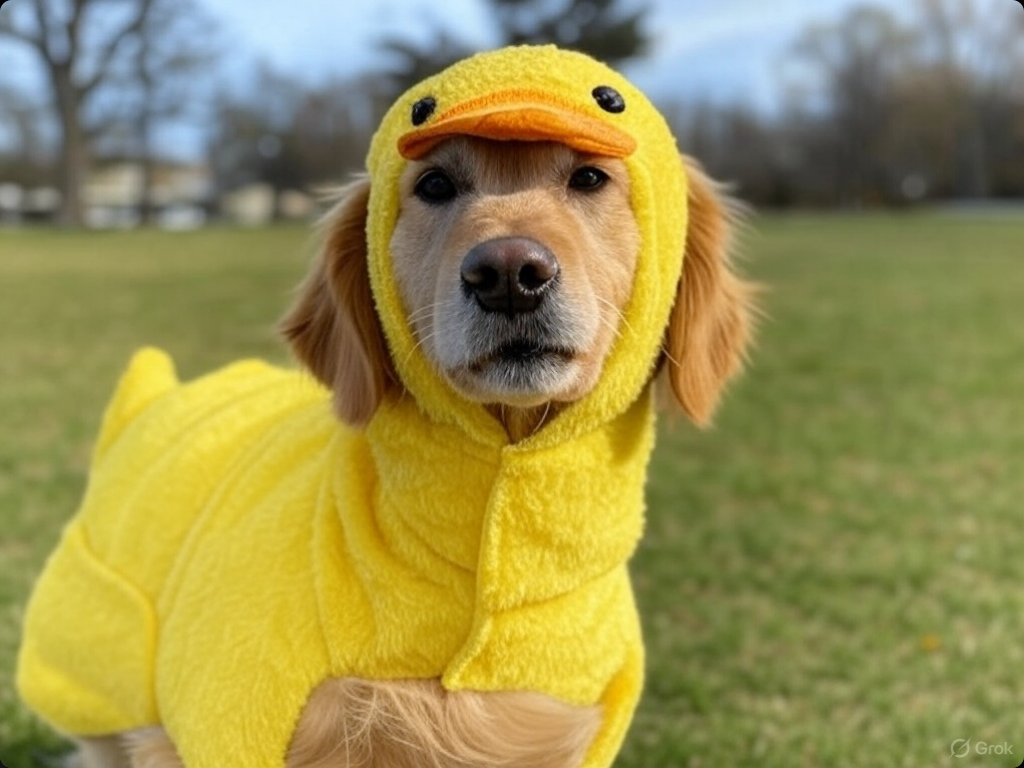
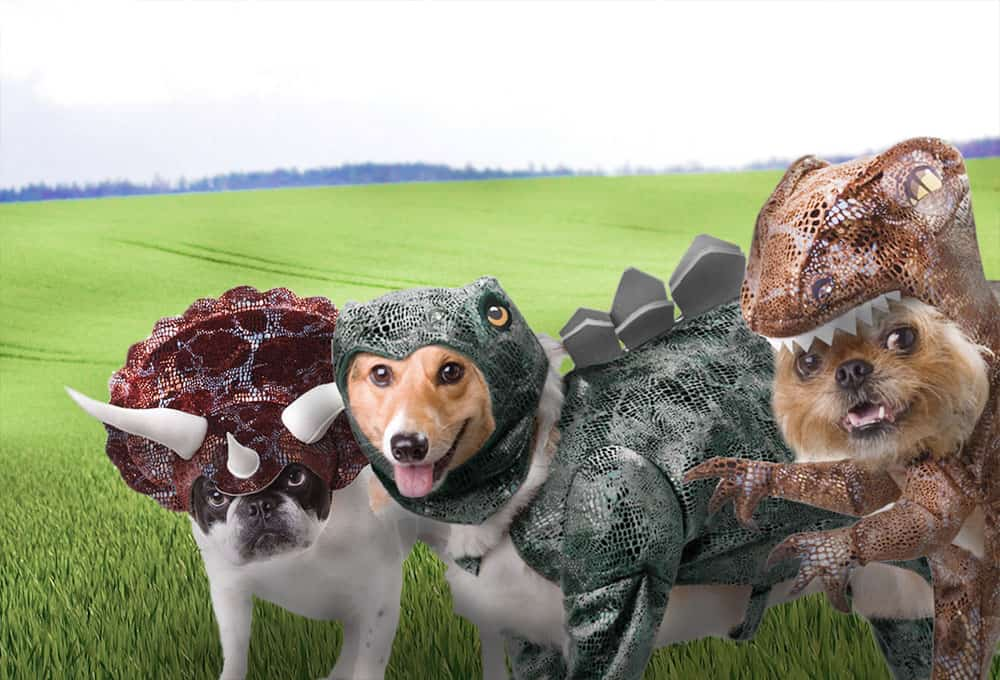

### Decoradores en Python

 - Permiten cambiar el comportamiento de una función (*sin modificarla*)
 - Reusar código fácilmente

<img align="right" width="1000" src="https://external-content.duckduckgo.com/iu/?u=http%3A%2F%2Fvignette4.wikia.nocookie.net%2Fpowerlisting%2Fimages%2Fd%2Fdf%2FIron-Man-Transform.gif%2Frevision%2Flatest%3Fcb%3D20150514015703&f=1&nofb=1" alt="Fancy Iron Man suitup">

### Todo en Python es un objeto!

Los objetos se definen por su **Identidad**, **estado** y **comportamiento**.


In [1]:
x = 1
print(id(1), type(x))

11639144 <class 'int'>


In [2]:
x.__add__(2)

3

In [ ]:
# Otros objetos
[1, 2, 3]    # listas
5.2          # flotantes
"hola"       # strings

### Funciones
Las funciones también son objetos

In [4]:
def saludar():
    print('Hola!')

In [5]:
id(saludar)

139825484544896

In [6]:
saludar.__name__

'saludar'

In [7]:
hablar = saludar    # asignamos la funcion a otra variable

In [8]:
hablar() # la podemos llamar

Hola!


## Decorador (definición no estricta)

Un decorador es una *función* **d** que recibe como parámetro otra *función* **a** y retorna una nueva *función* **r**.

- **d**: función decoradora
- **a**: función a decorar
- **r**: función decorada

## Código

In [3]:
def d(a):
    def r(*args, **kwargs):
        # comportamiento previo a la ejecución de a
        a(*args, **kwargs)
        # comportamiento posterior a la ejecución de a
    return r


## Código

In [4]:
def d(a):
    def r(*args, **kwargs):
        print("Inicia ejecucion de", a.__name__)
        result = a(*args, **kwargs)
        print("Fin ejecucion de", a.__name__)
        return result
        
    return r


## Manipulando funciones

In [5]:
def suma(x, y):
    return x + y

In [16]:
suma(1, 2)

3

In [17]:
suma_decorada = d(suma)
suma_decorada(1, 2)

Inicia ejecucion de suma
Fin ejecucion de suma


3

## Azúcar sintáctica
A partir de Python 2.4 se incorporó la notación con  **@**  para decorar funciones.

In [18]:
def suma(x, y):
    return x + y

suma = d(suma)
suma(1,2)

Inicia ejecucion de suma
Fin ejecucion de suma


3

In [19]:
@d
def suma(x, y):
    return x + y

## Ejemplo: Medir el tiempo de ejecución

In [6]:
import time

def timer(method):
    '''Decorator to time a function runtime'''
    def wrapper(*args, **kwargs):
        
        t0 = time.time()
        output = method(*args, **kwargs)
        dt = time.time() - t0
        
        print(f'<{method.__name__} finished in {dt} seconds>')
        return output
    
    return wrapper

In [9]:
@timer
def fib(n):
    values = [0, 1]
    while values[-2] < n:
        values.append(values[-2] + values[-1])
    return values

In [10]:
lista = fib(1000)
lista

<fib finished in 8.344650268554688e-06 seconds>


[0, 1, 1, 2, 3, 5, 8, 13, 21, 34, 55, 89, 144, 233, 377, 610, 987, 1597, 2584]

## Decoradores encadenados
Similar al concepto matemático de componer funciones.

In [2]:
@registrar_uso
@medir_tiempo_ejecucion
def mi_funcion(algunos, argumentos):
    # cuerpo de la funcion
    ...

NameError: name 'registrar_uso' is not defined

In [ ]:
def mi_funcion(algunos, argumentos):
    # cuerpo de la funcion
    
mi_funcion = registrar_uso(medir_tiempo_ejecucion(mi_funcion))

## Decoradores con parámetros?
 - Se denominan *Fábrica de decoradores*
 - Permiten tener decoradores más flexibles.
 - Ejemplo: un decorador que fuerce el tipo de retorno de una función

In [11]:
def to_string(user_function):
    def inner(*args, **kwargs):
        r = user_function(*args, **kwargs)
        return str(r)
    return inner

In [13]:
@to_string
def count():
    return []
count()

'[]'

## Envolvemos el decorador en una función externa 

In [60]:
def typer(t):
    record = []
    def decorator(user_function):
        
        def inner(*args, **kwargs):
            r = user_function(*args, **kwargs)
            record.append(r)
            return t(r)

        inner._record = record
        return inner
    
    return decorator

In [61]:
import numpy as np
@typer(bool)
def count(x, y):
    return 42


In [74]:
count._record

[42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42, 42]

## Clases decoradoras
 - Decoradores con estado
 - Código mejor organizado

In [34]:
class Decorador:
    def __init__(self, a):
        self.a = a
        self.variable = None
        
    def __call__(self, *args, **kwargs):
        # comportamiento previo a la ejecución de a
        r = self.a(*args, **kwargs)
        # comportamiento posterior a la ejecución de a
        return r

In [35]:
@Decorador
def edad():
    return 25.5

edad()   # se ejecuta el método __call__

25.5

## Decoradores (definición más estricta)
Un decorador es un *callable* **d** que recibe como parámetro un *objeto* **a** y retorna un nuevo *objeto* **r** (por lo general del mismo tipo que el orginal o con su misma interfaz).

- **d**: clase que defina el método <code>\_\_call\_\_</code>
- **a**: cualquier objeto
- **r**: objeto decorado

## Decorar clases
Identidad

In [75]:
def identidad(C):
    return C

In [76]:
identidad

1

## Decorar clases
Cambiar totalmente el comportamiento de una clase

In [80]:
def corromper(C):
    return print

In [82]:
@corromper
class A:
    pass

A

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

## Decorar clases
Reemplazar con una nueva clase

In [103]:
def reemplazar_con_X(C):
    class X():
        pass
    X.__qualname__ = f"C{id(X)}"
    return X

In [123]:
@reemplazar_con_X
class MiClase():
    pass

MiClase

__main__.C83347232

## Algunos decoradores comunes
La librería estándar de Python incluye <code>classmethod</code>, <code>staticmethod</code>, <code>property</code>

In [132]:
class Student:
    def __init__(self, first_name, last_name):
        self.first_name = first_name.capitalize()
        self.last_name = last_name.capitalize()
        self.full_name = ' '.join([self.first_name, self.last_name])
        
    @property
    def name(self):
        return self.full_name

    @name.setter
    def name(self, new_name):
        self.full_name = new_name.title()

    @classmethod
    def from_string(cls: Student, name_str: str) -> Student:
        first_name, last_name = map(str, name_str.split())
        student = cls(first_name, last_name)
        return student

    @staticmethod
    def is_full_name(name_str):
        names = name_str.split(' ')
        return len(names) > 1


In [133]:
s = Student('maria', 'perez');s.name = 'mariana perez';s.name;

In [134]:
Student.from_string('José Gonzalez');

In [136]:
Student.is_full_name('José Gonzalez')

True

# Context Managers en Python

## Introducción

- Los context managers en Python permiten gestionar recursos de manera eficiente, asegurando su correcta inicialización y liberación.
- Definen bloques de código con un entorno temporal de ejecución con estado definido.
- Se implementan comúnmente utilizando la declaración `with`, que simplifica el manejo de excepciones y la limpieza de recursos.
- Los context managers son útiles para trabajar con archivos, conexiones de red, bases de datos y otros recursos que requieren una gestión adecuada.

Por ejemplo para reemplazar este código de manejo de archivos

In [4]:
with open("rise.css") as fp:
    src = fp.read()

Se debe recurrir a este *try-catch*

In [5]:
try:
    fp = open("rise.css")
    src = fp.read()
finally:
    if not fp.closed:
        fp.close()

## Como se implementan?

El protocolo de context managers esta definido en [PEP 343 - The "with" Statement](https://peps.python.org/pep-0343/)
y define los métodos:

- `__enter__()`: Método llamado al entrar en el contexto. Prepara el entorno y retorna un objeto (si es necesario) que se asigna a la variable después de `as` en la declaración `with`.

- `__exit__(exc_type, exc_value, traceback)`: Método llamado al salir del contexto. Realiza la limpieza necesaria y maneja excepciones si ocurren. Retorna `True` si la excepción fue manejada, `False` en caso contrario.

**Ejemplo**

Este código define una clase `MiContexto` que implementa un context manager personalizado, el cual devuelve un valor (`value`) específico al entrar en el contexto y puede opcionalmente suprimir excepciones al salir, dependiendo del parámetro `quiet` proporcionado durante su inicialización.

In [6]:
class MiContexto:

    def __init__(self, value, quiet):
        self._value = value
        self._quiet = quiet
    
    def __enter__(self):
        return self._value

    def __exit__(self, *error):
        return bool(self._quiet)

In [7]:
with MiContexto(17, True) as coso:
    raise ValueError("lll")
    print(coso)

## `@contextmanager` de *contextlib*

El decorador `@contextmanager` de la biblioteca `contextlib` en Python simplifica la creación de context managers utilizando generadores, permitiendo definir el comportamiento de entrada y salida del contexto en una sola función, donde:
- el código antes del `yield` actúa como `__enter__`,
- el `yield` proporciona el valor de retorno, y
- el código después del `yield` funciona como `__exit__`, manejando automáticamente la gestión de excepciones y la limpieza de recursos.

In [8]:
import contextlib

@contextlib.contextmanager
def gen_context(value, quiet):
    try:
        yield value
    except Exception as err:
        if not quiet:
            raise err

with gen_context(25, True) as coso:
    raise ValueError()
    print(coso)

## Otras funcionalidades de contextlib

- `closing(thing)`: Crea un context manager que cierra `thing` al salir del contexto.
- `suppress(*exceptions)`: Context manager para suprimir excepciones específicas.
- `redirect_stdout(new_target)` y `redirect_stderr(new_target)`:
  Redirigen temporalmente la salida estándar o de error.
- `chdir(path)` Cambia temporalmente el directorio de trabajo actual al especificado por `path` al entrar en el contexto, y automáticamente restaura el directorio de trabajo original al salir del contexto.




## Cuándo crear Context Managers

1. **Gestión de recursos:**
   Para manejar la adquisición y liberación automática de recursos como archivos, conexiones de red o bases de datos.

2. **Configuración temporal:**
   Para establecer un estado temporal y restaurarlo automáticamente, como cambiar directorios de trabajo o modificar variables de entorno.

3. **Manejo de transacciones:**
   Para operaciones que deben completarse en su totalidad o revertirse, como transacciones de base de datos u operaciones atómicas de archivo.

4. **Bloqueos y sincronización:**
   Para gestionar la exclusión mutua en recursos compartidos, como bloqueos de threads o semáforos.

5. **Medición y logging:**
   Para rastrear tiempos de ejecución o registrar eventos de entrada/salida de manera automática.

6. **Manejo de excepciones simplificado:**
   Para encapsular patrones comunes de try/except/finally, como la supresión de errores específicos o reintentos automáticos.

7. **Configuración y limpieza de pruebas:**
   Para configurar y limpiar el estado entre pruebas unitarias, como la creación de directorios temporales o el mock de objetos.

8. **Cambios de estado global:** Para modificar temporalmente el estado global y restaurarlo automáticamente, como por ejemplo cambiar la precisión de números flotantes.